In [2]:
!pip install numpy
!pip install torch
!pip install xarray
!pip install matplotlib
!pip install tqdm
!pip install torch-geometric
!pip install torch-scatter
!pip install scikit-learn
!pip install netCDF4
!pip install wandb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 23.4 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 108.0/108.0 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for torch-scatter: filename=torch_scatter-2.1.2-cp310-cp310-linux_x86_64.whl size=3662077 sha256=cf116db4b0dd8f54505143533120b1c384dd19fa3708c0bb0957dd5f7d51ae98
  Stored in directory: /root/.cache/pip/wheels/92/f1/2b/3b46d54b134259f58c8363568569053248040859b1a145b3ce
Successfully built torch-scatter
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 60.0 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 54.1 MB/s eta 0:00:00


In [3]:
import os
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.data import Data, Batch
from torch_scatter import scatter_mean
import torch_geometric.transforms as T
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import netCDF4 as nc
from torch.optim.lr_scheduler import ReduceLROnPlateau
import wandb 

In [4]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [5]:
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


In [6]:
class SphericalDataset(Dataset):
    def __init__(self, file_path, transform=None, normalize=True):
        """
        Dataset for loading and preprocessing climate data on a spherical grid.
        
        Args:
            file_path: Path to the netCDF file
            transform: Any PyTorch Geometric transforms to apply
            normalize: Whether to normalize features
        """
        self.transform = transform
        
        # Load the netCDF file
        print(f"Loading data from {file_path}")
        self.ds = xr.open_dataset(file_path)
        
        # Extract basic information
        self.lats = self.ds.lat.values
        self.lons = self.ds.lon.values
        self.times = self.ds.time.values
        
        # Extract the temperature data (tas)
        self.tas = self.ds.tas.values
        
        # Get grid information for creating the graph
        self.nlat = len(self.lats)
        self.nlon = len(self.lons)
        
        # Create mesh grid for the coordinates
        lon_grid, lat_grid = np.meshgrid(self.lons, self.lats)
        self.grid_points = np.stack([lon_grid.flatten(), lat_grid.flatten()], axis=1)
        
        # Generate edge connections based on grid neighbors
        self.edge_index = self._create_graph_connections()
        
        # Normalize features if requested
        if normalize:
            self._normalize_features()
        
        print(f"Dataset created with {len(self.times)} timesteps, grid size: {self.nlat}x{self.nlon}")
    
    def _normalize_features(self):
        """Normalize the temperature data across all timesteps."""
        # Reshape to (timesteps, grid_points)
        data_reshaped = self.tas.reshape(len(self.times), -1)
        
        # Initialize and fit scaler
        self.scaler = StandardScaler()
        self.scaler.fit(data_reshaped)
        
        # Transform the data
        normalized_data = self.scaler.transform(data_reshaped)
        
        # Reshape back to original shape
        self.tas = normalized_data.reshape(self.tas.shape)
        
        print("Data normalized")
    
    def _create_graph_connections(self):
        """Create graph connections based on grid adjacency."""
        edges = []
        
        # Create a grid adjacency matrix
        for i in range(self.nlat):
            for j in range(self.nlon):
                node_idx = i * self.nlon + j
                
                # Connect to neighbors (4-connectivity)
                neighbors = []
                
                # North neighbor
                if i > 0:
                    neighbors.append((i-1) * self.nlon + j)
                
                # South neighbor
                if i < self.nlat - 1:
                    neighbors.append((i+1) * self.nlon + j)
                
                # West neighbor (with wraparound)
                west_j = (j - 1) % self.nlon
                neighbors.append(i * self.nlon + west_j)
                
                # East neighbor (with wraparound)
                east_j = (j + 1) % self.nlon
                neighbors.append(i * self.nlon + east_j)
                
                # Add edges
                for neighbor in neighbors:
                    edges.append([node_idx, neighbor])
        
        # Convert to torch tensor
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
        return edge_index
    
    def __len__(self):
        """Return the number of timesteps."""
        return len(self.times) - 1  # We predict the next timestep
    
    def __getitem__(self, idx):
        """Get a single timestep as graph data."""
        # Get the current and next temperature fields
        x = self.tas[idx].reshape(-1, 1).astype(np.float32)  # Current timestep as features
        y = self.tas[idx + 1].reshape(-1, 1).astype(np.float32)  # Next timestep as target
        
        # Create position features (latitude and longitude)
        pos = torch.tensor(self.grid_points, dtype=torch.float)
        
        # Create PyG data object
        data = Data(
            x=torch.tensor(x, dtype=torch.float),
            y=torch.tensor(y, dtype=torch.float),
            edge_index=self.edge_index,
            pos=pos
        )
        
        # Apply any transformations
        if self.transform:
            data = self.transform(data)
        
        return data

In [8]:
class SphericalGNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_layers=3, heads=4, dropout=0.1):
        """
        Spherical Graph Neural Network with Attention for climate modeling.
        
        Args:
            input_dim: Number of input features
            hidden_dim: Number of hidden features
            output_dim: Number of output features
            num_layers: Number of GNN layers
            heads: Number of attention heads
            dropout: Dropout probability
        """
        super(SphericalGNN, self).__init__()
        
        self.num_layers = num_layers
        
        # Initial feature embedding
        self.embedding = nn.Linear(input_dim, hidden_dim)
        
        # GAT layers
        self.convs = nn.ModuleList()
        self.batch_norms = nn.ModuleList()
        
        # First layer
        self.convs.append(GATConv(hidden_dim, hidden_dim, heads=heads, dropout=dropout))
        self.batch_norms.append(nn.BatchNorm1d(hidden_dim * heads))
        
        # Middle layers
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_dim * heads, hidden_dim, heads=heads, dropout=dropout))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim * heads))
        
        # Final layer
        self.convs.append(GATConv(hidden_dim * heads, hidden_dim, heads=1, dropout=dropout))
        self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        
        # Output prediction layer
        self.output_layer = nn.Linear(hidden_dim, output_dim)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        self.act = nn.ELU()
    
    def forward(self, data):
        """Forward pass of the model."""
        x, edge_index = data.x, data.edge_index
        
        # Initial embedding
        x = self.embedding(x)
        
        # Apply GAT layers
        for i in range(self.num_layers):
            x = self.convs[i](x, edge_index)
            x = self.batch_norms[i](x)
            x = self.act(x)
            x = self.dropout(x)
        
        # Output layer
        x = self.output_layer(x)
        
        return x

In [9]:
class EarlyStopping:
    """Early stopping to prevent overfitting"""
    def __init__(self, patience=7, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.Inf
        self.delta = delta
        self.path = path
        
    def __call__(self, val_loss, model):
        score = -val_loss
        
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0
            
    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=50, 
               early_stopping_patience=10, grad_clip=1.0, log_wandb=False):
    """
    Train the model with progress tracking and validation.
    
    Args:
        model: The neural network model
        train_loader: DataLoader for training data
        val_loader: DataLoader for validation data
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler
        num_epochs: Number of training epochs
        early_stopping_patience: Patience for early stopping
        grad_clip: Gradient clipping value
        log_wandb: Whether to log metrics to Weights & Biases
    """
    # Initialize early stopping
    early_stopping = EarlyStopping(patience=early_stopping_patience, verbose=True, path='best_model.pt')
    
    # Training history
    history = {
        'train_loss': [],
        'val_loss': [],
        'learning_rate': []
    }
    
    # Start training
    for epoch in range(num_epochs):
        # Training phase
        model.train()
        train_losses = []
        
        # Create progress bar for training
        train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
        
        for batch in train_pbar:
            # Move batch to device
            batch = batch.to(device)
            
            # Zero gradients
            optimizer.zero_grad()
            
            # Forward pass
            outputs = model(batch)
            loss = criterion(outputs, batch.y)
            
            # Backward pass and optimize
            loss.backward()
            
            # Gradient clipping
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            
            optimizer.step()
            
            # Track loss
            train_losses.append(loss.item())
            train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # Calculate average training loss
        avg_train_loss = np.mean(train_losses)
        history['train_loss'].append(avg_train_loss)
        
        # Validation phase
        model.eval()
        val_losses = []
        
        # Create progress bar for validation
        val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Valid]')
        
        with torch.no_grad():
            for batch in val_pbar:
                # Move batch to device
                batch = batch.to(device)
                
                # Forward pass
                outputs = model(batch)
                loss = criterion(outputs, batch.y)
                
                # Track loss
                val_losses.append(loss.item())
                val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
        
        # Calculate average validation loss
        avg_val_loss = np.mean(val_losses)
        history['val_loss'].append(avg_val_loss)
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        history['learning_rate'].append(current_lr)
        
        # Print epoch summary
        print(f'Epoch {epoch+1}/{num_epochs} - '
              f'Train Loss: {avg_train_loss:.4f}, '
              f'Val Loss: {avg_val_loss:.4f}, '
              f'LR: {current_lr:.6f}')
        
        # Log to wandb if enabled
        if log_wandb:
            wandb.log({
                'epoch': epoch,
                'train_loss': avg_train_loss,
                'val_loss': avg_val_loss,
                'learning_rate': current_lr
            })
        
        # Learning rate scheduler step
        scheduler.step(avg_val_loss)
        
        # Early stopping check
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping triggered!")
            break
    
    # Load best model
    model.load_state_dict(torch.load('best_model.pt'))
    
    return model, history

In [11]:
def plot_training_history(history):
    """Plot training and validation loss curves."""
    plt.figure(figsize=(12, 4))
    
    # Plot loss curves
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Training Loss')
    plt.plot(history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    
    # Plot learning rate
    plt.subplot(1, 2, 2)
    plt.plot(history['learning_rate'])
    plt.xlabel('Epoch')
    plt.ylabel('Learning Rate')
    plt.title('Learning Rate Schedule')
    plt.yscale('log')
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.show()

In [12]:
def evaluate_model(model, test_loader, criterion):
    """Evaluate the model on the test set."""
    model.eval()
    test_losses = []
    
    # Create progress bar for evaluation
    test_pbar = tqdm(test_loader, desc='Evaluating')
    
    predictions = []
    targets = []
    
    with torch.no_grad():
        for batch in test_pbar:
            # Move batch to device
            batch = batch.to(device)
            
            # Forward pass
            outputs = model(batch)
            loss = criterion(outputs, batch.y)
            
            # Store predictions and targets
            predictions.append(outputs.cpu().numpy())
            targets.append(batch.y.cpu().numpy())
            
            # Track loss
            test_losses.append(loss.item())
            test_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate average test loss
    avg_test_loss = np.mean(test_losses)
    print(f'Test Loss: {avg_test_loss:.4f}')
    
    # Concatenate predictions and targets
    predictions = np.concatenate(predictions)
    targets = np.concatenate(targets)
    
    # Calculate metrics
    mse = np.mean((predictions - targets) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(predictions - targets))
    
    print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}')
    
    return {
        'test_loss': avg_test_loss,
        'mse': mse,
        'rmse': rmse,
        'mae': mae,
        'predictions': predictions,
        'targets': targets
    }

In [13]:
# Import the necessary function from PyTorch Geometric
from torch_geometric.loader import DataLoader as PyGDataLoader

# Replace the standard DataLoader with PyG's DataLoader in the main function
def main():
    # Configuration
    config = {
        'data_path': '/kaggle/input/cimp6-fraction/cmip6_tas_cesm2_historical.nc',
        'batch_size': 32,
        'hidden_dim': 64,
        'num_layers': 3,
        'attention_heads': 4,
        'dropout': 0.2,
        'learning_rate': 0.001,
        'weight_decay': 1e-5,
        'num_epochs': 50,
        'early_stopping_patience': 10,
        'grad_clip': 1.0,
        'test_size': 0.15,
        'val_size': 0.15,
        'log_wandb': False  # Set to True to enable Weights & Biases logging
    }
    
    # Initialize wandb if enabled
    if config['log_wandb']:
        wandb.init(project="climate-spherical-gnn", config=config)
    
    # Load and preprocess data
    dataset = SphericalDataset(config['data_path'], normalize=True)
    
    # Split data into train, validation, and test sets
    num_samples = len(dataset)
    indices = list(range(num_samples))
    
    # First split: train + val and test
    train_val_indices, test_indices = train_test_split(
        indices, test_size=config['test_size'], random_state=42
    )
    
    # Second split: train and val
    train_indices, val_indices = train_test_split(
        train_val_indices, test_size=config['val_size']/(1-config['test_size']), random_state=42
    )
    
    print(f"Training samples: {len(train_indices)}")
    print(f"Validation samples: {len(val_indices)}")
    print(f"Test samples: {len(test_indices)}")
    
    # Create PyG data loaders instead of standard DataLoader
    train_loader = PyGDataLoader(
        [dataset[i] for i in train_indices],
        batch_size=config['batch_size'],
        shuffle=True
    )
    
    val_loader = PyGDataLoader(
        [dataset[i] for i in val_indices],
        batch_size=config['batch_size'],
        shuffle=False
    )
    
    test_loader = PyGDataLoader(
        [dataset[i] for i in test_indices],
        batch_size=config['batch_size'],
        shuffle=False
    )
    
    # Initialize model
    input_dim = 1  # Temperature
    output_dim = 1  # Predicted temperature
    
    model = SphericalGNN(
        input_dim=input_dim,
        hidden_dim=config['hidden_dim'],
        output_dim=output_dim,
        num_layers=config['num_layers'],
        heads=config['attention_heads'],
        dropout=config['dropout']
    ).to(device)
    
    print(model)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    
    # Learning rate scheduler - Fix the deprecated verbose parameter
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5,
        verbose=False  # Changed from True to False to avoid the warning
    )
    
    # Train model
    start_time = time.time()
    model, history = train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=config['num_epochs'],
        early_stopping_patience=config['early_stopping_patience'],
        grad_clip=config['grad_clip'],
        log_wandb=config['log_wandb']
    )
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")
    
    # Plot training history
    plot_training_history(history)
    
    # Evaluate on test set
    results = evaluate_model(model, test_loader, criterion)
    
    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'config': config,
        'history': history,
        'test_results': results
    }, 'spherical_gnn_model.pt')
    
    print("Model and results saved!")
    
    # Close wandb if enabled
    if config['log_wandb']:
        wandb.finish()

In [15]:
# Memory optimization for the SphericalGNN model and training process
import os
import gc

# Add this environment variable setting at the beginning of your script
# This helps with memory fragmentation issues
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

def memory_optimized_main():
    # Configuration with memory-optimized settings
    config = {
        'data_path': '/kaggle/input/cimp6-fraction/cmip6_tas_cesm2_historical.nc',
        'batch_size': 8,  # Reduced batch size
        'hidden_dim': 32,  # Reduced hidden dimension
        'num_layers': 2,  # Reduced number of layers
        'attention_heads': 2,  # Reduced number of attention heads
        'dropout': 0.2,
        'learning_rate': 0.001,
        'weight_decay': 1e-5,
        'num_epochs': 50,
        'early_stopping_patience': 10,
        'grad_clip': 1.0,
        'test_size': 0.15,
        'val_size': 0.15,
        'log_wandb': False
    }
    
    # Force garbage collection before loading data
    gc.collect()
    torch.cuda.empty_cache()
    
    # Load and preprocess data
    dataset = SphericalDataset(config['data_path'], normalize=True)
    
    # Split data into train, validation, and test sets
    num_samples = len(dataset)
    indices = list(range(num_samples))
    
    # First split: train + val and test
    train_val_indices, test_indices = train_test_split(
        indices, test_size=config['test_size'], random_state=42
    )
    
    # Second split: train and val
    train_indices, val_indices = train_test_split(
        train_val_indices, test_size=config['val_size']/(1-config['test_size']), random_state=42
    )
    
    print(f"Training samples: {len(train_indices)}")
    print(f"Validation samples: {len(val_indices)}")
    print(f"Test samples: {len(test_indices)}")
    
    # Create PyG data loaders with smaller batch size
    from torch_geometric.loader import DataLoader as PyGDataLoader
    
    train_loader = PyGDataLoader(
        [dataset[i] for i in train_indices],
        batch_size=config['batch_size'],
        shuffle=True
    )
    
    val_loader = PyGDataLoader(
        [dataset[i] for i in val_indices],
        batch_size=config['batch_size'],
        shuffle=False
    )
    
    test_loader = PyGDataLoader(
        [dataset[i] for i in test_indices],
        batch_size=config['batch_size'],
        shuffle=False
    )
    
    # Force garbage collection again
    gc.collect()
    torch.cuda.empty_cache()
    
    # Initialize model with smaller dimensions
    input_dim = 1  # Temperature
    output_dim = 1  # Predicted temperature
    
    model = SphericalGNN(
        input_dim=input_dim,
        hidden_dim=config['hidden_dim'],
        output_dim=output_dim,
        num_layers=config['num_layers'],
        heads=config['attention_heads'],
        dropout=config['dropout']
    ).to(device)
    
    print(model)
    
    # Loss function and optimizer
    criterion = nn.MSELoss()
    optimizer = optim.Adam(
        model.parameters(),
        lr=config['learning_rate'],
        weight_decay=config['weight_decay']
    )
    
    # Learning rate scheduler
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=5,
        verbose=False
    )
    
    # Optional: Enable gradient checkpointing to save memory
    # This recomputes intermediate activations during backward pass instead of storing them
    model.convs.apply(lambda m: m.enable_checkpoint() if hasattr(m, 'enable_checkpoint') else None)
    
    # Modify train_model function to include memory clearing
    def memory_efficient_train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, 
                                    num_epochs=50, early_stopping_patience=10, grad_clip=1.0, log_wandb=False):
        """
        Memory-efficient training function with regular garbage collection
        """
        # Initialize early stopping
        early_stopping = EarlyStopping(patience=early_stopping_patience, verbose=True, path='best_model.pt')
        
        # Training history
        history = {
            'train_loss': [],
            'val_loss': [],
            'learning_rate': []
        }
        
        # Start training
        for epoch in range(num_epochs):
            # Training phase
            model.train()
            train_losses = []
            
            # Create progress bar for training
            train_pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]')
            
            for batch in train_pbar:
                # Move batch to device
                batch = batch.to(device)
                
                # Zero gradients
                optimizer.zero_grad()
                
                # Forward pass
                outputs = model(batch)
                loss = criterion(outputs, batch.y)
                
                # Backward pass and optimize
                loss.backward()
                
                # Gradient clipping
                nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                
                optimizer.step()
                
                # Track loss
                train_losses.append(loss.item())
                train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
                
                # Clear memory after each batch
                del outputs, loss, batch
                torch.cuda.empty_cache()
            
            # Calculate average training loss
            avg_train_loss = np.mean(train_losses)
            history['train_loss'].append(avg_train_loss)
            
            # Force garbage collection
            gc.collect()
            torch.cuda.empty_cache()
            
            # Validation phase
            model.eval()
            val_losses = []
            
            # Create progress bar for validation
            val_pbar = tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Valid]')
            
            with torch.no_grad():
                for batch in val_pbar:
                    # Move batch to device
                    batch = batch.to(device)
                    
                    # Forward pass
                    outputs = model(batch)
                    loss = criterion(outputs, batch.y)
                    
                    # Track loss
                    val_losses.append(loss.item())
                    val_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
                    
                    # Clear memory after each batch
                    del outputs, loss, batch
                    torch.cuda.empty_cache()
            
            # Calculate average validation loss
            avg_val_loss = np.mean(val_losses)
            history['val_loss'].append(avg_val_loss)
            
            # Get current learning rate
            current_lr = optimizer.param_groups[0]['lr']
            history['learning_rate'].append(current_lr)
            
            # Print epoch summary
            print(f'Epoch {epoch+1}/{num_epochs} - '
                f'Train Loss: {avg_train_loss:.4f}, '
                f'Val Loss: {avg_val_loss:.4f}, '
                f'LR: {current_lr:.6f}')
            
            # Log to wandb if enabled
            if log_wandb:
                wandb.log({
                    'epoch': epoch,
                    'train_loss': avg_train_loss,
                    'val_loss': avg_val_loss,
                    'learning_rate': current_lr
                })
            
            # Learning rate scheduler step
            scheduler.step(avg_val_loss)
            
            # Early stopping check
            early_stopping(avg_val_loss, model)
            if early_stopping.early_stop:
                print("Early stopping triggered!")
                break
            
            # Force garbage collection after each epoch
            gc.collect()
            torch.cuda.empty_cache()
        
        # Load best model
        model.load_state_dict(torch.load('best_model.pt'))
        
        return model, history
    
    # Train model with memory efficient function
    start_time = time.time()
    model, history = memory_efficient_train_model(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        num_epochs=config['num_epochs'],
        early_stopping_patience=config['early_stopping_patience'],
        grad_clip=config['grad_clip'],
        log_wandb=config['log_wandb']
    )
    
    training_time = time.time() - start_time
    print(f"Training completed in {training_time:.2f} seconds")
    
    # Plot training history
    plot_training_history(history)
    
    # Memory-efficient evaluation function
    def memory_efficient_evaluate(model, test_loader, criterion):
        """Memory-efficient evaluation function"""
        model.eval()
        test_losses = []
        
        # Create progress bar for evaluation
        test_pbar = tqdm(test_loader, desc='Evaluating')
        
        all_predictions = []
        all_targets = []
        
        with torch.no_grad():
            for batch in test_pbar:
                # Move batch to device
                batch = batch.to(device)
                
                # Forward pass
                outputs = model(batch)
                loss = criterion(outputs, batch.y)
                
                # Store predictions and targets
                all_predictions.append(outputs.cpu().numpy())
                all_targets.append(batch.y.cpu().numpy())
                
                # Track loss
                test_losses.append(loss.item())
                test_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
                
                # Clear memory
                del outputs, loss, batch
                torch.cuda.empty_cache()
        
        # Calculate average test loss
        avg_test_loss = np.mean(test_losses)
        print(f'Test Loss: {avg_test_loss:.4f}')
        
        # Concatenate predictions and targets
        predictions = np.concatenate(all_predictions)
        targets = np.concatenate(all_targets)
        
        # Calculate metrics
        mse = np.mean((predictions - targets) ** 2)
        rmse = np.sqrt(mse)
        mae = np.mean(np.abs(predictions - targets))
        
        print(f'MSE: {mse:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}')
        
        return {
            'test_loss': avg_test_loss,
            'mse': mse,
            'rmse': rmse,
            'mae': mae
        }
    
    # Evaluate on test set with memory-efficient function
    results = memory_efficient_evaluate(model, test_loader, criterion)
    
    # Save model
    torch.save({
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'config': config,
        'history': history,
        'test_results': results
    }, 'spherical_gnn_model.pt')
    
    print("Model and results saved!")
    
    # Close wandb if enabled
    if config['log_wandb']:
        wandb.finish()


Loading data from /kaggle/input/cimp6-fraction/cmip6_tas_cesm2_historical.nc
Data normalized
Dataset created with 1980 timesteps, grid size: 192x288
Training samples: 1385
Validation samples: 297
Test samples: 297
SphericalGNN(
  (embedding): Linear(in_features=1, out_features=32, bias=True)
  (convs): ModuleList(
    (0): GATConv(32, 32, heads=2)
    (1): GATConv(64, 32, heads=1)
  )
  (batch_norms): ModuleList(
    (0): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (output_layer): Linear(in_features=32, out_features=1, bias=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (act): ELU(alpha=1.0)
)


/usr/local/lib/python3.10/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50 [Train]:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 1/50 [Valid]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 1/50 - Train Loss: 0.4207, Val Loss: 0.3436, LR: 0.001000
Validation loss decreased (inf --> 0.343560). Saving model...


...

Epoch 29/50 - Train Loss: 0.3529, Val Loss: 0.3401, LR: 0.000250
EarlyStopping counter: 9 out of 10


Epoch 30/50 [Train]:   0%|          | 0/174 [00:00<?, ?it/s]

Epoch 30/50 [Valid]:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 30/50 - Train Loss: 0.3533, Val Loss: 0.3390, LR: 0.000250
EarlyStopping counter: 10 out of 10
Early stopping triggered!
Training completed in 1121.02 seconds


<ipython-input-15-badf285e297d>:235: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))


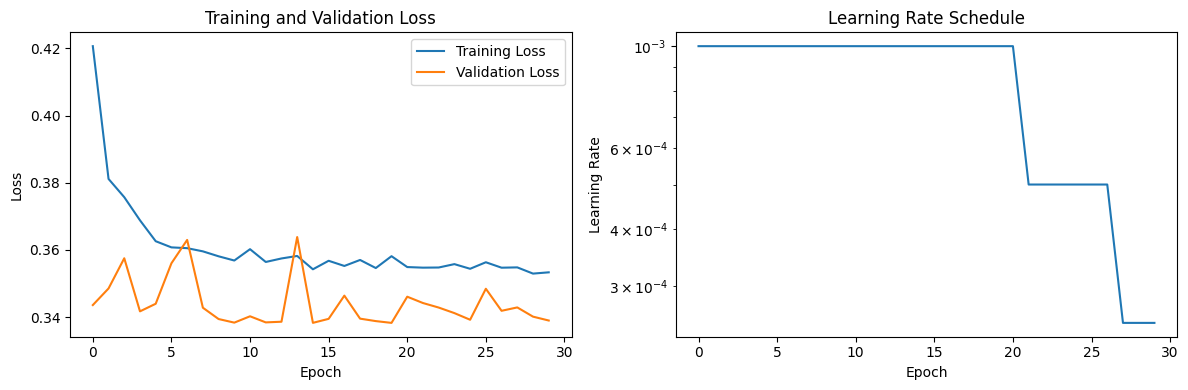

Evaluating:   0%|          | 0/38 [00:00<?, ?it/s]

Test Loss: 0.3448
MSE: 0.3446, RMSE: 0.5870, MAE: 0.4862
Model and results saved!


In [17]:
# if __name__ == "__main__":
#     main()

if __name__ == "__main__":
    memory_optimized_main()

In [19]:
# Clear GPU cache
torch.cuda.empty_cache()

!PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True